In [4]:
# import libraries 

import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
import sqlite3

In [5]:
print("All libraries imported successfully!")

All libraries imported successfully!


In [6]:
import sqlite3

print("SQLite3 is installed!")
print("SQLite version:", sqlite3.sqlite_version)

SQLite3 is installed!
SQLite version: 3.50.4


# 1. import database / data

In [7]:
conn = sqlite3.connect('customer_churn.db')
sql_query = """

      SELECT name
      FROM sqlite_master
      WHERE type='table'
      
"""

tables = pd.read_sql(sql_query, conn)

# create dataframe for each table

for table_name in tables['name']:
    df = pd.read_sql(f"SELECT * FROM {table_name}", conn)
    globals() [f"df_{table_name}"] = df
    print (f"Created dataframe: df_{table_name}")

conn.close()

Created dataframe: df_db_customer
Created dataframe: df_db_subscription
Created dataframe: df_db_support


In [8]:
# Print table names and column names
conn = sqlite3. connect('customer_churn.db')

for table_name in tables['name']:
    print (f"\nTable Name: {table_name} ")
    
    # Get column information
    
    columns_query = f"PRAGMA table_info({table_name});"
    columns = pd.read_sql (columns_query, conn)
    print ("Columns:")
    print (columns ['name'].tolist())

# CLose connection
conn. close()


Table Name: db_customer 
Columns:
['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests', 'pincode']

Table Name: db_subscription 
Columns:
['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score']

Table Name: db_support 
Columns:
['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'comment']


# 2. Data Cleaning 

In [9]:
df_db_customer.head()

,customerid,name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,None,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,None,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None


In [10]:
df_db_customer.tail()

,customerid,name,country,state,gender,dob,interests,pincode
16,0020-JDNXP,rikim,India,Meghalaya,Female,1994-08-19 00:00:00,None,None
17,0021-IKXGC,vishakha,India,Rajasthan,Female,2000-09-02 00:00:00,None,None
18,0022-TCJCI,raghvendra,India,Telangana,Male,1983-12-30 00:00:00,None,None
19,0023-HGHWL,rishabh,India,Uttar Pradesh,Men,1991-05-14 00:00:00,None,None
20,0023-UYUPN,sudevi,India,Maharashtra,Women,1977-10-06 00:00:00,None,None


In [11]:
df_db_customer

,customerid,name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,None,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,None,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None
5,0013-MHZWF,durga,None,Delhi,Women,1988-12-10 00:00:00,None,None
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21 00:00:00,None,None
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14 00:00:00,None,None
8,0015-UOCOJ,maya,None,Kathmandu,Women,1985-07-07 00:00:00,None,None
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29 00:00:00,None,None


In [12]:
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  21 non-null     object
 1   name        21 non-null     object
 2   country     18 non-null     object
 3   state       21 non-null     object
 4   gender      21 non-null     object
 5   dob         21 non-null     object
 6   interests   4 non-null      object
 7   pincode     0 non-null      object
dtypes: object(8)
memory usage: 1.4+ KB


# a. rename col - name 
# b. drop columns - interest and pincode
# c. change data type - dob 
# d. data standardization - gender
# e. fix missing values - country 

In [13]:
# a. rename col - name 

df_db_customer.rename(columns = {'name' : 'customer_name'}, inplace = True)

In [14]:
df_db_customer

,customerid,customer_name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,None,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,None,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None
5,0013-MHZWF,durga,None,Delhi,Women,1988-12-10 00:00:00,None,None
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21 00:00:00,None,None
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14 00:00:00,None,None
8,0015-UOCOJ,maya,None,Kathmandu,Women,1985-07-07 00:00:00,None,None
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29 00:00:00,None,None


In [15]:
# b. drop columns - interests and pincode

# df_db_customer.drop(df_db_customer.columns[-2:], axis=1)
# df_db_customer.drop(df_db_customer.columns[6:], axis=1)



df_db_customer.drop(columns = ['interests','pincode'], inplace = True)

df_db_customer





,customerid,customer_name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00
5,0013-MHZWF,durga,None,Delhi,Women,1988-12-10 00:00:00
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21 00:00:00
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14 00:00:00
8,0015-UOCOJ,maya,None,Kathmandu,Women,1985-07-07 00:00:00
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29 00:00:00


In [16]:
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerid     21 non-null     object
 1   customer_name  21 non-null     object
 2   country        18 non-null     object
 3   state          21 non-null     object
 4   gender         21 non-null     object
 5   dob            21 non-null     object
dtypes: object(6)
memory usage: 1.1+ KB


# c. change data type - dob 

In [17]:
df_db_customer['dob'] = pd.to_datetime(df_db_customer['dob']) 

In [18]:
# d. data standardization - gender

# df_db_customer['gender'].unique()

df_db_customer['gender'].replace({'Men':'Male','Women':'Female'}, inplace = True)

In [19]:
df_db_customer['gender'].unique()

array(['Male', 'Female'], dtype=object)

In [20]:
df_db_customer

,customerid,customer_name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05
5,0013-MHZWF,durga,None,Delhi,Female,1988-12-10
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14
8,0015-UOCOJ,maya,None,Kathmandu,Female,1985-07-07
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29


In [21]:
# e. fix missing values - country

df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob
5,0013-MHZWF,durga,None,Delhi,Female,1988-12-10
8,0015-UOCOJ,maya,None,Kathmandu,Female,1985-07-07
12,0018-NYROU,chitra,None,Telangana,Female,2004-12-01


In [22]:
df_db_customer[['country','state']]

,country,state
0,India,Maharashtra
1,India,Karnataka
2,India,Delhi
3,India,Nagaland
4,India,Delhi
5,None,Delhi
6,India,Meghalaya
7,India,Rajasthan
8,None,Kathmandu
9,Nepal,Kathmandu


In [23]:
# country and state unique pair 

df_db_customer.dropna(subset = ["country"]).set_index("state")["country"].to_dict()

{'Maharashtra': 'India',
 'Karnataka': 'India',
 'Delhi': 'India',
 'Nagaland': 'India',
 'Meghalaya': 'India',
 'Rajasthan': 'India',
 'Kathmandu': 'Nepal',
 'Uttar Pradesh': 'India',
 'Telangana': 'India'}

In [24]:
state_country_mapping = df_db_customer.dropna(subset = ["country"]).set_index("state")["country"].to_dict()

In [25]:
df_db_customer['country'].fillna(df_db_customer['state'].map(state_country_mapping), inplace = True)

In [26]:
df_db_customer

,customerid,customer_name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05
5,0013-MHZWF,durga,India,Delhi,Female,1988-12-10
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14
8,0015-UOCOJ,maya,Nepal,Kathmandu,Female,1985-07-07
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29


In [27]:
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob


In [28]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,None,None,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,None,None,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,None,None,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [29]:
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     object 
 1   subscription_start_date  21 non-null     object 
 2   subscription_type        21 non-null     object 
 3   renewal_date             21 non-null     object 
 4   plan_type                21 non-null     object 
 5   contract_type            21 non-null     object 
 6   cancellation_date        6 non-null      object 
 7   cancellation_reason      6 non-null      object 
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 1.9+ KB


In [30]:
date_column = ['subscription_start_date','renewal_date','cancellation_date']

df_db_subscription[date_column] = df_db_subscription[date_column].apply(pd.to_datetime)

In [31]:
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     object        
 1   subscription_start_date  21 non-null     datetime64[ns]
 2   subscription_type        21 non-null     object        
 3   renewal_date             21 non-null     datetime64[ns]
 4   plan_type                21 non-null     object        
 5   contract_type            21 non-null     object        
 6   cancellation_date        6 non-null      datetime64[ns]
 7   cancellation_reason      6 non-null      object        
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
dtypes: datetime64[ns](3), float64(1), int64(2), object(5)
memory usage: 1.9+ KB


In [32]:
df_db_support.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,None
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,None


In [33]:
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      object
 1   complaint_date  9 non-null      object
 2   escalations     9 non-null      object
 3   csat_score      9 non-null      int64 
 4   col_1           0 non-null      object
 5   comment         4 non-null      object
dtypes: int64(1), object(5)
memory usage: 564.0+ bytes


In [34]:
df_db_support.drop(columns = ['col_1','comment'],inplace = True)

In [35]:
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      object
 1   complaint_date  9 non-null      object
 2   escalations     9 non-null      object
 3   csat_score      9 non-null      int64 
dtypes: int64(1), object(3)
memory usage: 420.0+ bytes


In [36]:
df_db_support['complaint_date'] = df_db_support['complaint_date'].apply(pd.to_datetime)

In [37]:
df_db_support.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      9 non-null      object        
 1   complaint_date  9 non-null      datetime64[ns]
 2   escalations     9 non-null      object        
 3   csat_score      9 non-null      int64         
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 420.0+ bytes


# 3. Feature Engineering and Data Analysis 

In [38]:
# create a new column using existing column - churn flag 

df_db_subscription['churn_flag'] = np.where(df_db_subscription['cancellation_date'].notna(), 1, 0)

In [39]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1


In [40]:
# first fix support table duplicates then merge

df = (df_db_subscription 
    .merge(df_db_customer, on = 'customerid', how = 'left')
    .merge(df_db_support, on = 'customerid', how = 'left') )

In [41]:
df_db_subscription.shape

(21, 12)

In [42]:
df.shape

(23, 20)

In [43]:
df_db_subscription['customerid'].nunique()

21

In [44]:
df_db_customer['customerid'].nunique()

21

In [45]:
df_db_support['customerid'].nunique()

7

In [46]:
df_db_support['customerid'].size

9

In [47]:
df_db_support

,customerid,complaint_date,escalations,csat_score
0,0003-MKNFE,2024-08-28,N,60
1,0003-MKNFE,2024-08-28,Y,10
2,0013-EXCHZ,2024-01-20,Y,20
3,0013-MHZWF,2025-03-18,N,90
4,0013-SMEOE,2024-11-01,N,30
5,0017-IUDMW,2024-04-10,Y,25
6,0019-EFAEP,2024-09-27,Y,30
7,0022-TCJCI,2024-09-13,Y,10
8,0022-TCJCI,2024-09-14,N,90


In [48]:
df_db_support['complaint_count'] = df_db_support.groupby('customerid')['customerid'].transform('count')

In [49]:
df_db_support = df_db_support.sort_values('complaint_date').drop_duplicates('customerid', keep = 'last')

In [50]:
# merge Dataframe (df)

df = (df_db_subscription 
    .merge(df_db_customer, on = 'customerid', how = 'left')
    .merge(df_db_support, on = 'customerid', how = 'left') )

In [51]:
df.shape

(21, 21)

In [52]:
df.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,churn_flag,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,...,0,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0,2.0
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,...,0,lalita,India,Delhi,Female,1978-02-15,NaT,NaN,NaN,NaN
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,...,0,mohan,India,Nagaland,Male,2001-08-30,NaT,NaN,NaN,NaN
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,1,mira,India,Delhi,Female,1990-05-05,2024-01-20,Y,20.0,1.0


In [53]:
df.to_csv('churn_data.csv', index = False)

# Data Analysis

In [54]:
# 1. Churn Rate 

In [55]:
print([repr(col) for col in df.columns if 'churn' in str(col).lower()])

["'churn_score'", "'churn_flag'"]


In [56]:
df['churn_flag'].mean()

np.float64(0.2857142857142857)

In [57]:
churn_rate = df['churn_flag'].mean()*100
print("Churn_Rate = ", round(churn_rate,2),"%")

Churn_Rate =  28.57 %


In [58]:
# 2. Retention Rate 

retention_rate = 100 - churn_rate 
print("Retention_Rate = ", round(retention_rate,2),"%")

Retention_Rate =  71.43 %


In [59]:
# 3. Churn by Plan Type

churn_by_plan = df.groupby('plan_type')['churn_flag'].mean().mul(100).round(2).reset_index(name = 'churn_rate_percentage')

In [60]:
churn_by_plan

,plan_type,churn_rate_percentage
0,Basic,60.00
1,Premium,14.29
2,Standard,22.22


In [61]:
# 4(a). churn by state + sum(revenue) & count of users 

In [62]:
churn_by_state = df.groupby('state').agg(
    churn_users = ('churn_flag','sum'),
    total_users = ('customerid','count'),
    total_revenue = ('monthly_charges','sum')
).reset_index()

churn_by_state['churn_rate_percentage'] = (
    churn_by_state['churn_users'] / churn_by_state['total_users']  * 100
).round(2)

In [63]:
churn_by_state

,state,churn_users,total_users,total_revenue,churn_rate_percentage
0,Delhi,1,4,52.96,25.00
1,Karnataka,2,2,20.98,100.00
2,Kathmandu,0,2,20.98,0.00
3,Maharashtra,0,3,50.97,0.00
4,Meghalaya,2,3,42.97,66.67
5,Nagaland,0,1,22.99,0.00
6,Rajasthan,0,2,36.98,0.00
7,Telangana,1,2,30.98,50.00
8,Uttar Pradesh,0,2,115.98,0.00


In [64]:
# 4(b). churn by subscription type + sum(revenue) & count of users 

In [65]:
churn_by_st = df.groupby('subscription_type').agg(
    churn_users=('churn_flag', 'sum'),
    total_users=('customerid', 'count'),
    total_revenue=('monthly_charges', 'sum')
).reset_index()

churn_by_st['churn_rate_percentage'] = (
    churn_by_st['churn_users'] /
    churn_by_st['total_users'] * 100
).round(2)


In [66]:
churn_by_st

,subscription_type,churn_users,total_users,total_revenue,churn_rate_percentage
0,Organic,0,9,145.91,0.00
1,Paid,1,6,174.94,16.67
2,Refferal,5,6,74.94,83.33


In [67]:
# 5. Average Revenue Per User

In [68]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count'],
      dtype='object')

In [69]:
df['monthly_charges'].mean()

np.float64(18.847142857142856)

In [70]:
ARPU = df['monthly_charges'].mean()
print("ARPU = ", round(ARPU,2),"%")

ARPU =  18.85 %


In [71]:
# 6. Average Customer Tenure

# count of days user has used our services : either Cancellation date or Current date 

In [153]:
today = pd.Timestamp.today()

In [154]:
df['subscription_start_date'] = pd.to_datetime(
    df['subscription_start_date'],
    errors='coerce'
)

df['cancellation_date'] = pd.to_datetime(
    df['cancellation_date'],
    errors='coerce'
)

In [155]:
df['tenure_days'] = np.where(

    df['cancellation_date'].notna(),
    
    (df['cancellation_date'] - df['subscription_start_date']).dt.days,

    (today - df['subscription_start_date']).dt.days    
)

In [156]:
df.head(3)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count,tenure_days
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,12,0,keshav,India,Maharashtra,Male,1982-04-12,NaN,0.0,NaN,NaN,1989.0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,1.0,10.0,2.0,1501.0
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,34,0,lalita,India,Delhi,Female,1978-02-15,NaN,0.0,NaN,NaN,1374.0


In [76]:
avg_tenure = df['tenure_days'].mean()
print("AVG Tenure (Days) = ", round(avg_tenure))

AVG Tenure (Days) =  1524


In [77]:
# 7. Revenue at Risk - Revenue lost from churned users 

In [78]:
revenue_lost = df.loc[df['churn_flag']==1,'monthly_charges'].sum()
print("Revenue_Lost (Rs 'K') = ",revenue_lost )

Revenue_Lost (Rs 'K') =  73.94


In [79]:
# 8. Escalation Rate 

escalation_rate = (df['escalations']== 'Y').mean()*100
print("Escalation_Rate = ",round(escalation_rate,2),"%")

Escalation_Rate =  19.05 %


In [80]:
# 9. Avg Complaint Per User 

In [81]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days'],
      dtype='object')

In [82]:
avg_complaints = df['complaint_count'].sum() / df['customerid'].nunique()
print("AVG_Complaints = ",round(avg_complaints,2))

AVG_Complaints =  0.43


In [150]:
# 10. Correlation: Escalation vs Churn

# Encode Escalations
df['escalations'] = df['escalations'].map({
    'Y': 1,
    'N': 0
}).fillna(0)

# Calculate correlation
correlation = df['escalations'].corr(df['churn_flag'])

print("Correlation between Escalation and Churn =", round(correlation, 2))

Correlation between Escalation and Churn = 0.77


In [84]:
df = pd.read_csv("churn_data.csv")

df['escalations'].value_counts(dropna=False)

escalations
NaN    14
Y       4
N       3
Name: count, dtype: int64

In [85]:
# Encode escalations
df['escalations'] = df['escalations'].map({
    'Y': 1,
    'N': 0
})

In [86]:
df['escalations'].value_counts(dropna=False)

escalations
NaN    14
1.0     4
0.0     3
Name: count, dtype: int64

In [87]:
# 11. create a column using existing col - churn Risk 

conditions = [
    (df['churn_score'] < 50),
    (df['churn_score'] >= 50) & (df['churn_score'] < 70), 
    (df['churn_score'] >= 70)
]
choices = ['low', 'med', 'high']
df['churn_risk'] = np.select(conditions, choices, default = 'unkown')

In [88]:
df[['churn_score','churn_risk']].tail()

,churn_score,churn_risk
16,62,med
17,27,low
18,99,high
19,7,low
20,47,low


In [89]:
df.columns.tolist()

['customerid',
 'subscription_start_date',
 'subscription_type',
 'renewal_date',
 'plan_type',
 'contract_type',
 'cancellation_date',
 'cancellation_reason',
 'monthly_charges',
 'cltv',
 'churn_score',
 'churn_flag',
 'customer_name',
 'country',
 'state',
 'gender',
 'dob',
 'complaint_date',
 'escalations',
 'csat_score',
 'complaint_count',
 'churn_risk']

In [121]:
pd.set_option('display.max_columns', None)

df.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count,churn_risk
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaN,NaN,13.99,627,12,0,keshav,India,Maharashtra,Male,1982-04-12,NaN,NaN,NaN,NaN,low
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,1.0,10.0,2.0,high
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaN,NaN,6.99,210,34,0,lalita,India,Delhi,Female,1978-02-15,NaN,NaN,NaN,NaN,low
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaN,NaN,22.99,1725,8,0,mohan,India,Nagaland,Male,2001-08-30,NaN,NaN,NaN,NaN,low
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1,mira,India,Delhi,Female,1990-05-05,2024-01-20,1.0,20.0,1.0,high


# Visualization using Matplotlib

In [122]:
df_visual = df.copy()

In [123]:
df_visual.shape

(21, 22)

In [93]:
df_visual['cancellation_date'] = pd.to_datetime(
    df_visual['cancellation_date'],
    errors='coerce'
)

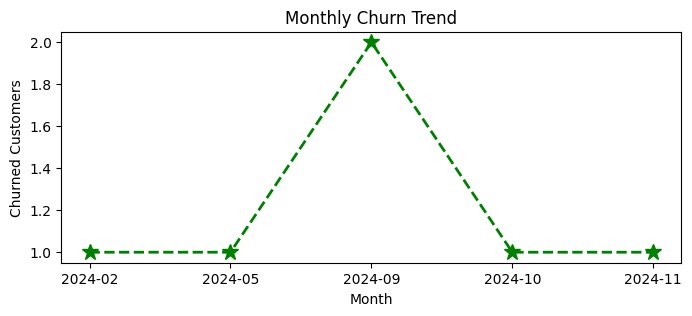

In [94]:
#4.1 Monthly Churn Trend (Time Series KPI)

df_visual['cancellation_month'] = df_visual['cancellation_date'].dt.to_period('M')

churn_trend = df_visual[df_visual['churn_flag'] == 1].groupby('cancellation_month').size()
    
plt.figure(figsize=(8,3))
plt.plot(churn_trend.index.astype(str), churn_trend.values, color='green', marker='*', linestyle='dashed', linewidth=2, markersize=12)
    
plt.title('Monthly Churn Trend')
plt.xlabel('Month')
plt.ylabel('Churned Customers')
plt. show()

In [95]:
# 4.2 Churn by Plann Type

df_visual.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count,churn_risk,cancellation_month
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,12,0,keshav,India,Maharashtra,Male,1982-04-12,NaN,NaN,NaN,NaN,low,NaT
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,1.0,10.0,2.0,high,2024-09
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,34,0,lalita,India,Delhi,Female,1978-02-15,NaN,NaN,NaN,NaN,low,NaT
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,8,0,mohan,India,Nagaland,Male,2001-08-30,NaN,NaN,NaN,NaN,low,NaT
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1,mira,India,Delhi,Female,1990-05-05,2024-01-20,1.0,20.0,1.0,high,2024-02


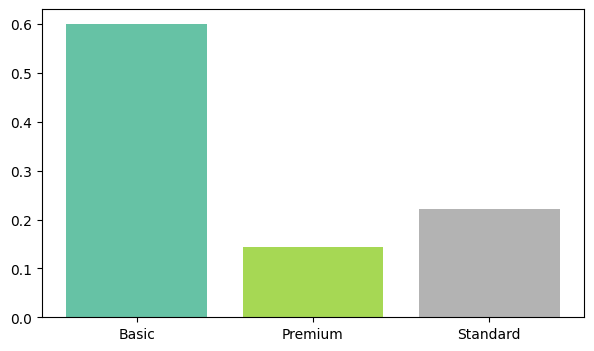

In [96]:
churn_plan = df_visual.groupby('plan_type')['churn_flag'].mean()

# colors = ['yellow', 'purple', 'blue']

colors = plt.cm.Set2(np.linspace(0, 1, len(churn_plan)))

plt.figure(figsize=(7,4))

plt.bar(churn_plan.index, churn_plan.values, color = colors)
plt. show()

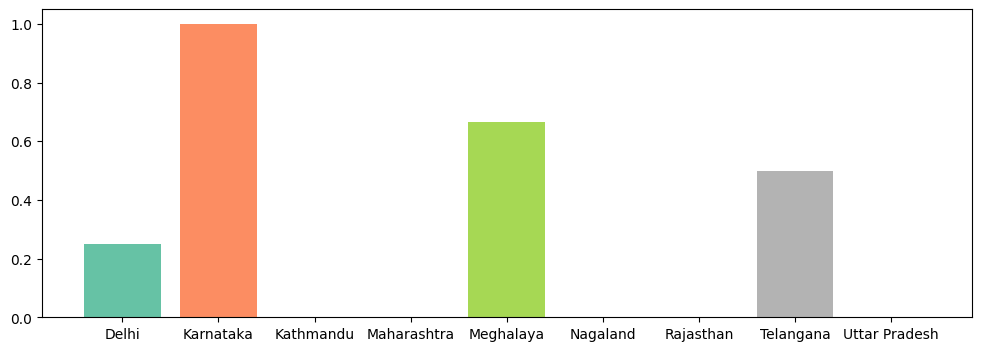

In [97]:
# 4.3 Churn by States

churn_plan = df_visual.groupby('state')['churn_flag'].mean()

# colors = ['yellow', 'purple', 'blue']

colors = plt.cm.Set2(np.linspace(0, 1, len(churn_plan)))

plt.figure(figsize=(12,4))
plt.bar(churn_plan.index, churn_plan.values, color = colors)
plt.show()

In [98]:
import warnings
warnings.filterwarnings("ignore")

In [126]:
# Correct method of encoding - based on priority

df_encoded = df_visual[['plan_type', 'contract_type', 'churn_score', 'churn_flag', 'churn_risk', 'escalations']]

order_mappings = {
'plan_type' : ['Basic', 'Standard', 'Premium'],
'contract_type' : ['Monthly', 'Annual'],
'churn_risk': ['low', 'med', 'high' ]
}

for col, order in order_mappings.items():
    df_encoded[col] = pd.Categorical(df_encoded[col].astype('category'), categories=order, ordered=True).codes

In [124]:
df_visual[['plan_type', 'contract_type', 'churn_score', 'churn_flag', 'churn_risk', 'escalations' ]].head()df['escalations'] = df['escalations'].fillna(0)

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,Standard,Annual,12,0,low,NaN
1,Premium,Annual,91,1,high,1.0
2,Basic,Monthly,34,0,low,NaN
3,Premium,Annual,8,0,low,NaN
4,Standard,Monthly,88,1,high,1.0


In [132]:
df_encoded['escalations'] = df['escalations'].fillna(0)

In [133]:
df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,1,1,12,0,0,0.0
1,2,1,91,1,2,1.0
2,0,0,34,0,0,0.0
3,2,1,8,0,0,0.0
4,1,0,88,1,2,1.0


<Axes: >

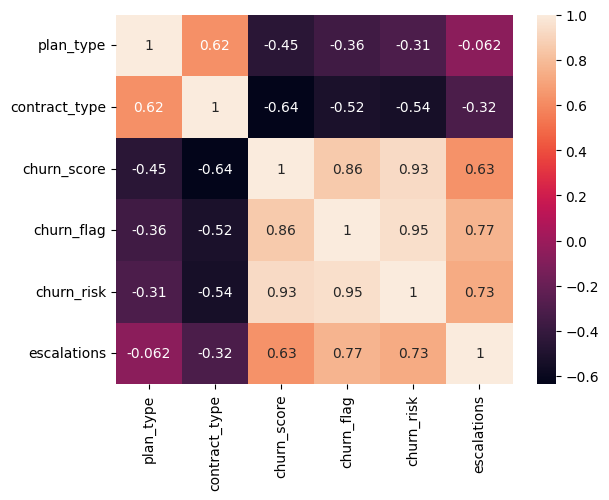

In [134]:
# Heatmap (Correlation Matrix)

sns.heatmap(df_encoded.corr(),annot=True)

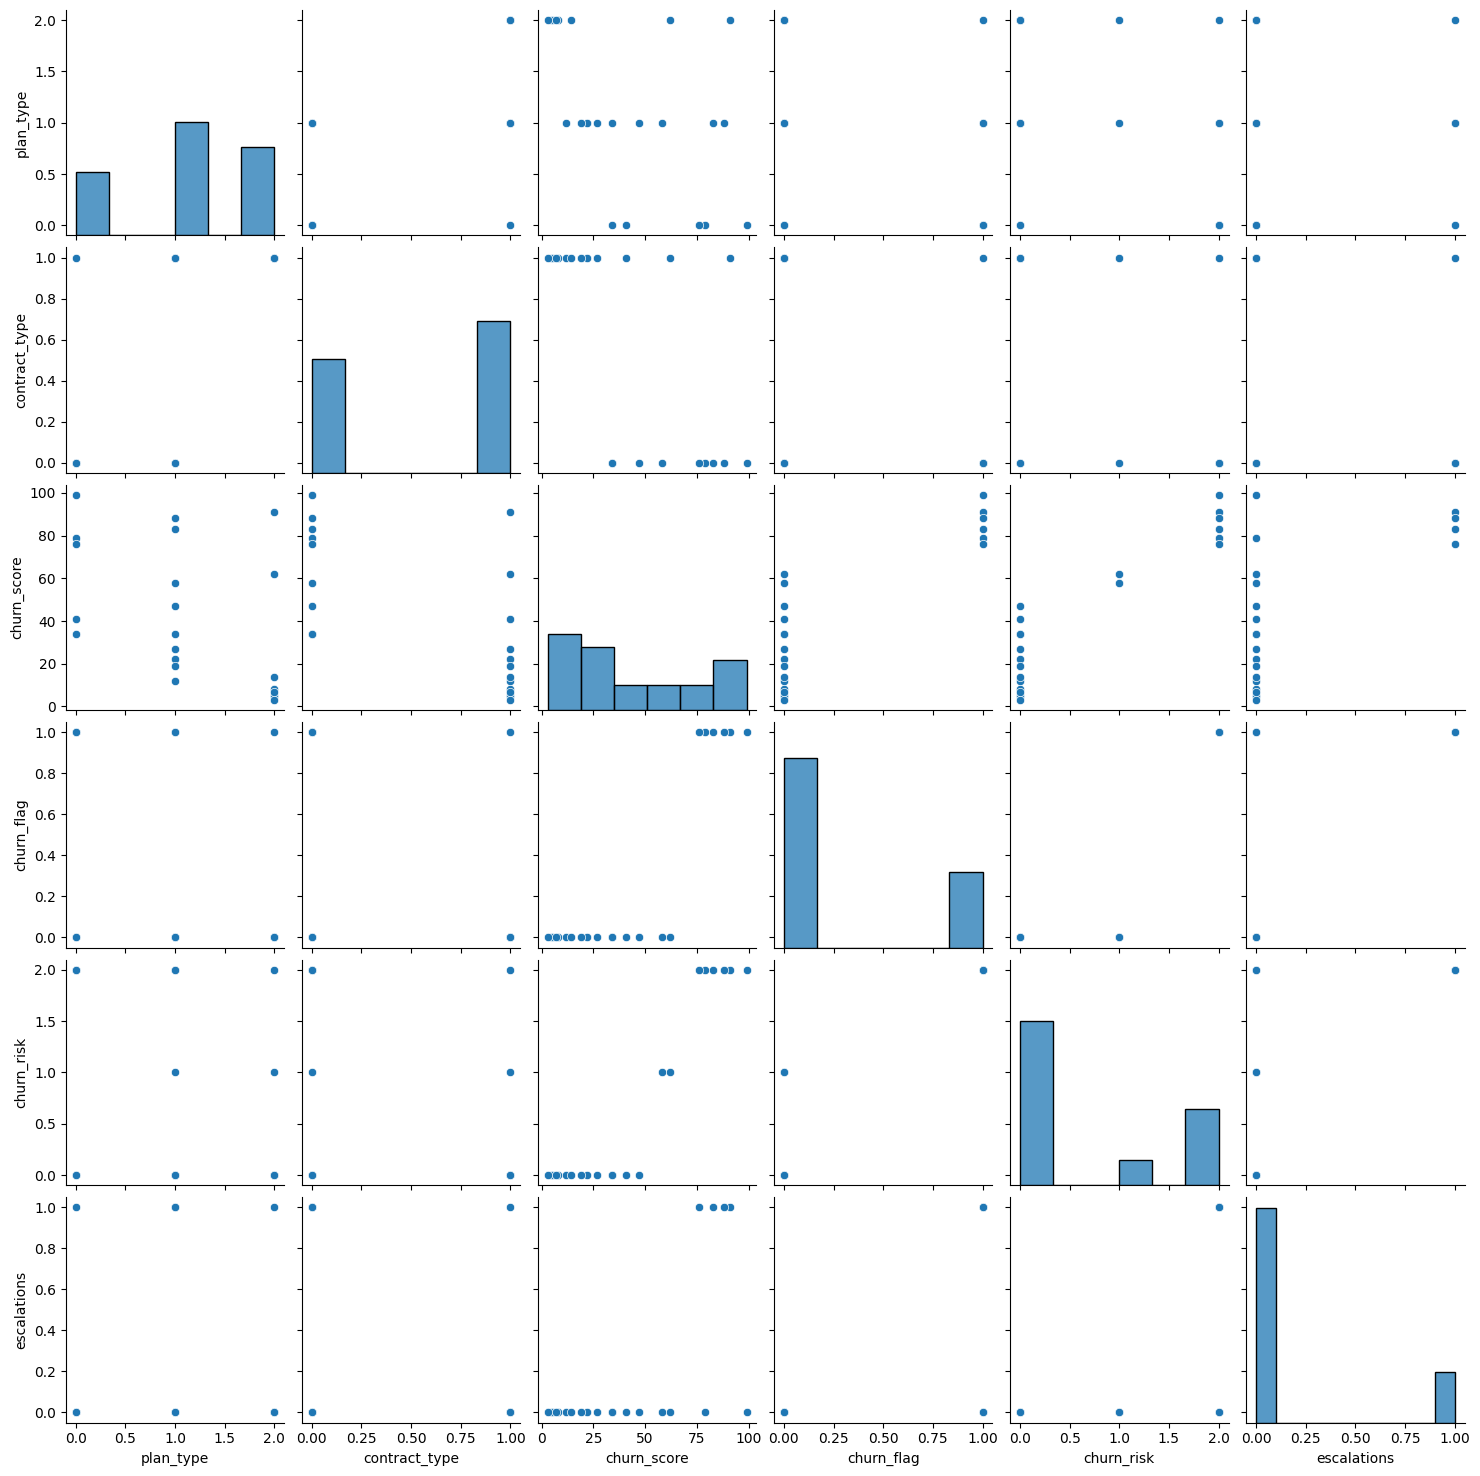

In [135]:
# pairplot - relationship in a dataset 

sns.pairplot(df_encoded)

In [136]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'churn_risk'],
      dtype='object')

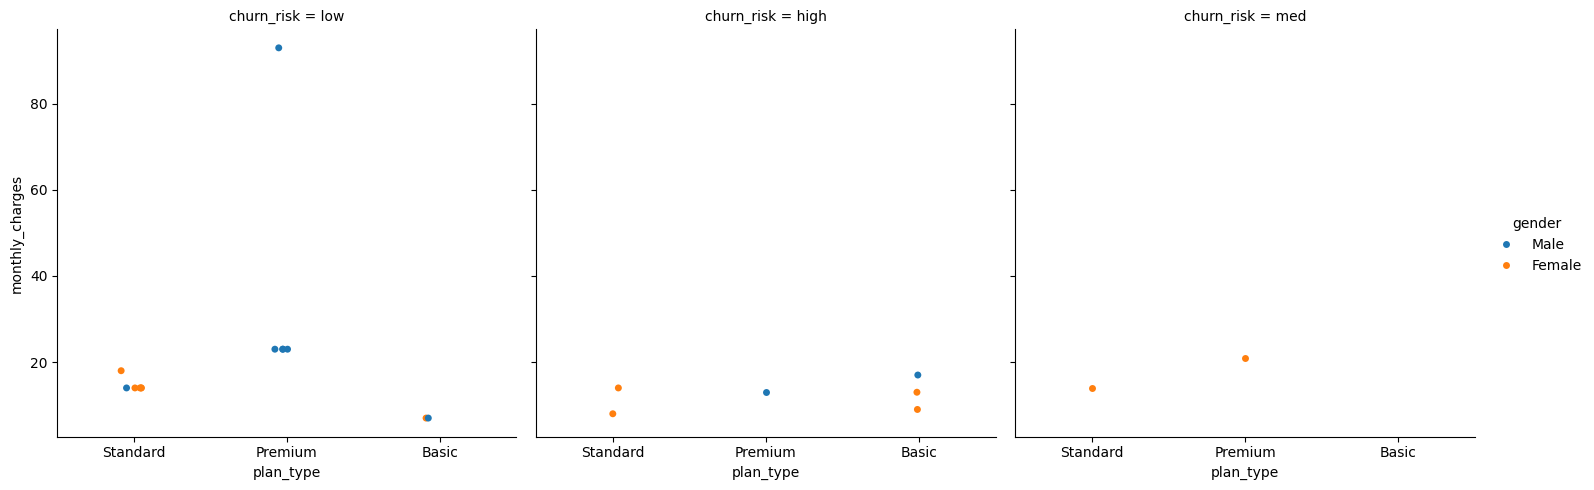

In [137]:
# categorical plot/facegrid plot - multi dimensional comparison

sns.catplot(data = df_visual,
    x = 'plan_type',
    y = 'monthly_charges',
    hue = 'gender',   
    col = 'churn_risk',)



# Pivot Table

In [143]:
pd.pivot_table(
    df_visual,
    index = 'plan_type',
    values = 'churn_flag',
    aggfunc = 'mean'
).reset_index()

,plan_type,churn_flag
0,Basic,0.600000
1,Premium,0.142857
2,Standard,0.222222


In [146]:
pd.pivot_table(
    
    df_visual,
    
    index = 'plan_type',
    
    values = ['customerid','monthly_charges','churn_flag'],
    
    aggfunc = {

        'customerid' : 'nunique' ,

        'monthly_charges' : 'sum' , 

        'churn_flag' : 'mean'
    }
).reset_index()

,plan_type,churn_flag,customerid,monthly_charges
0,Basic,0.600000,5,52.95
1,Premium,0.142857,7,218.93
2,Standard,0.222222,9,123.91


In [159]:
# Estimated Customer Lifetime Value

df['tenure_months'] = df['tenure_days'] / 30.44

df['estimated_cltv'] = (
    df['monthly_charges'] * df['tenure_months']
)

df[['customerid', 'monthly_charges', 'tenure_months', 'estimated_cltv']].head()

,customerid,monthly_charges,tenure_months,estimated_cltv
0,0002-ORFBO,13.99,65.341656,914.129763
1,0003-MKNFE,12.99,49.310118,640.538436
2,0004-TLHLJ,6.99,45.137976,315.514455
3,0011-IGKFF,22.99,87.516426,2012.002628
4,0013-EXCHZ,13.99,13.764783,192.569317
